# DA25M502_IDL_Assignment_4_Submissions_Coding
- Roll No : DA25M502
- Name : Amardeep Kumar

## Imports

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets
from torchvision.transforms import ToTensor
import torchvision.transforms as transforms
from torch.utils.data import DataLoader,Subset,random_split,TensorDataset
from sklearn.decomposition import PCA

## Question 2 : (Programming Question) Load the CIFAR-10 dataset.
----

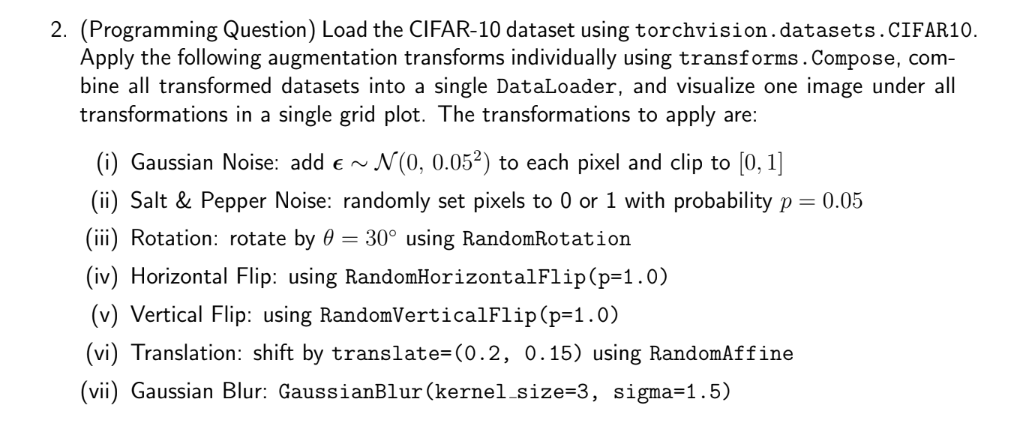

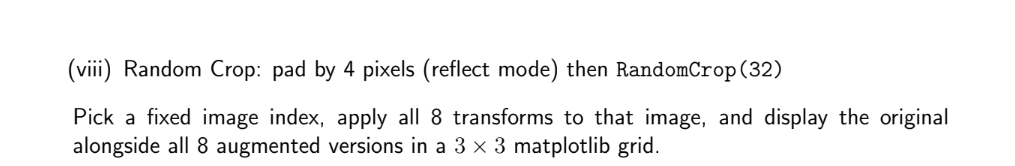

this is  CIFAR-10 dataset analysis using Pytorch implementation..


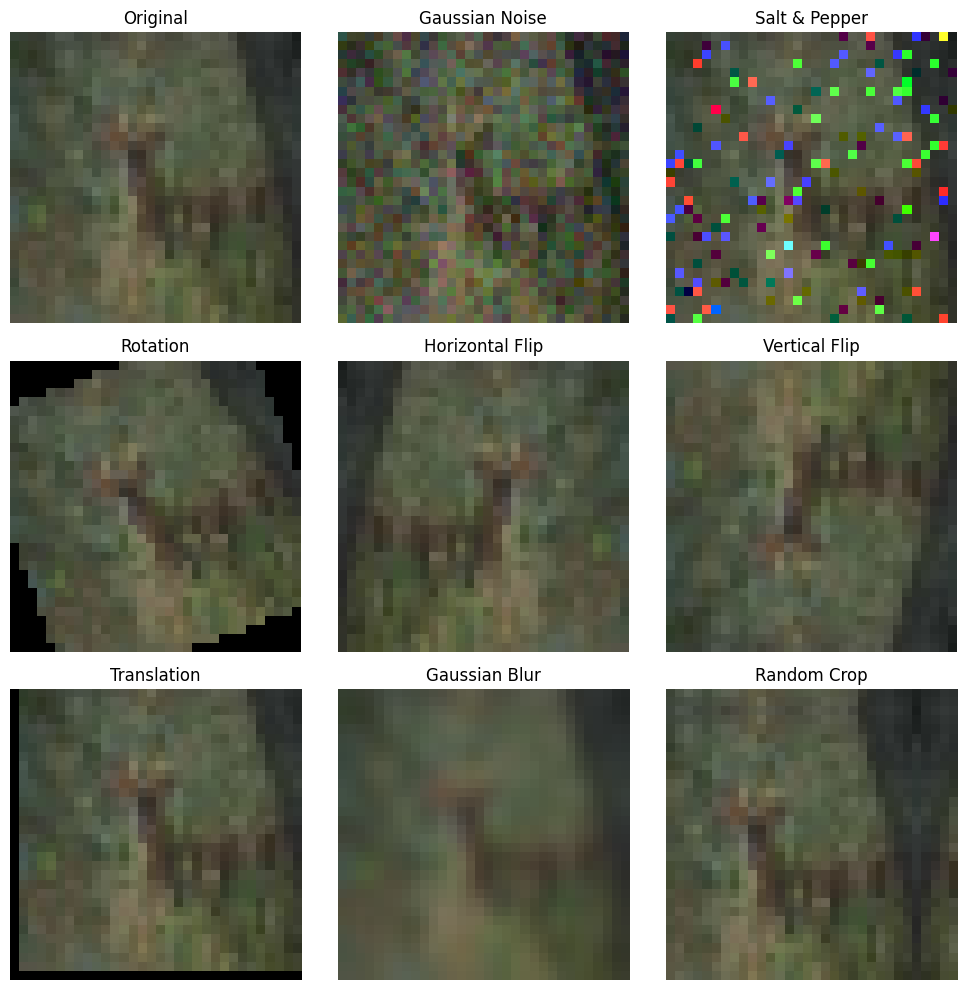

In [9]:
print(f"this is  CIFAR-10 dataset analysis using Pytorch implementation..")
print("=="*50)

#==================================
# 1. Gaussian Noise
#==================================
class AddGaussianNoise(object):
    def __init__(self, mean=0.0, std=0.05):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        noise = torch.randn_like(tensor) * self.std + self.mean
        return torch.clamp(tensor + noise, 0., 1.)

#===========================================
# 2. Salt and Paper Noise
#===========================================
class SaltPepperNoise(object):
    def __init__(self, prob=0.05):
        self.prob = prob

    def __call__(self, tensor):
        rand = torch.rand_like(tensor)
        tensor[rand < self.prob/2] = 0.0   # pepper
        tensor[rand > 1 - self.prob/2] = 1.0  # salt
        return tensor

#============================================
# 3.transformation list
#============================================
transform_list = {
    "Original": transforms.ToTensor(),

    "Gaussian Noise": transforms.Compose([
        transforms.ToTensor(),
        AddGaussianNoise(std=0.05)
    ]),

    "Salt & Pepper": transforms.Compose([
        transforms.ToTensor(),
        SaltPepperNoise(prob=0.05)
    ]),

    "Rotation": transforms.Compose([
        transforms.RandomRotation(30),
        transforms.ToTensor()
    ]),

    "Horizontal Flip": transforms.Compose([
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor()
    ]),

    "Vertical Flip": transforms.Compose([
        transforms.RandomVerticalFlip(p=1.0),
        transforms.ToTensor()
    ]),

    "Translation": transforms.Compose([
        transforms.RandomAffine(degrees=0, translate=(0.2, 0.15)),
        transforms.ToTensor()
    ]),

    "Gaussian Blur": transforms.Compose([
        transforms.GaussianBlur(kernel_size=3, sigma=1.5),
        transforms.ToTensor()
    ]),

    "Random Crop": transforms.Compose([
        transforms.Pad(4, padding_mode='reflect'),
        transforms.RandomCrop(32),
        transforms.ToTensor()
    ])
}

#========================================
# 4. Data Setup
#========================================
dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True
)
index = 10   # any fixed index
img, label = dataset[index]

index = 10   # any fixed index
img, label = dataset[index]

images = []
titles = []

for name, transform in transform_list.items():
    transformed_img = transform(img)
    images.append(transformed_img)
    titles.append(name)


#======================================
# 5. plotting
#======================================
plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3, 3, i+1)

    img_np = images[i].permute(1, 2, 0).numpy()
    plt.imshow(img_np)
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()


#============================================
# 6. comine into single dataloader
#===========================================
datasets_list = []

for transform in transform_list.values():
    ds = datasets.CIFAR10(
        root="./data",
        train=True,
        download=False,
        transform=transform
    )
    datasets_list.append(ds)

combined_dataset = torch.utils.data.ConcatDataset(datasets_list)

loader = torch.utils.data.DataLoader(combined_dataset, batch_size=64, shuffle=True)

## Question 3: (Programming Question) Bagging Classifier via Maximum Voting on Fashion-MNIST using Pytorch
----


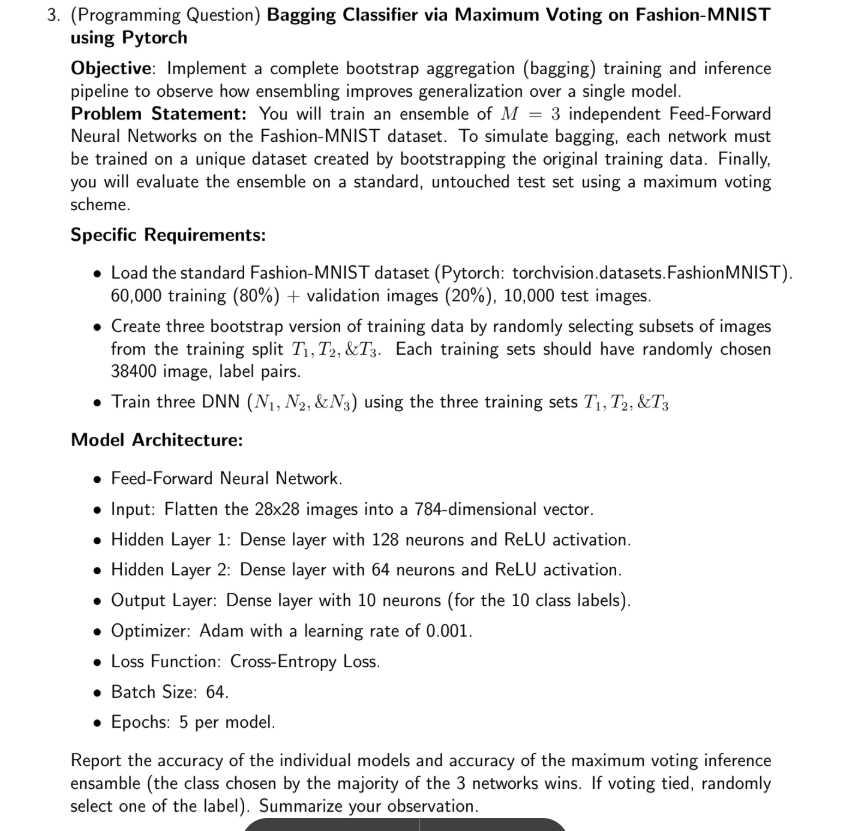

In [13]:
print(f"this is  Bagging Classifier via Maximum Voting on Fashion-MNIST using Pytorch implementation..")
print("=="*50)
#============================================
# 1. Load the Dataset
#============================================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))   # 28x28 = 784
])

training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transform,
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=transform,
)

print("dataset split summary.")
print(f"this is total training data(training + validation) i.e. 80% of the Fashion MNIST Dataset : {len(training_data)}")
print(f"this is total test data i.e. 20% of the Fashion MNIST Dataset : {len(test_data)}\n")

#======================================================
# 2. Bootstrap Sample
# 38400 images in each bootstrap i.e :
# total taining images = 60000 , 80% of this = 48000
# 80% of 48000 is the 38400
#======================================================
def q3_bootstrap_dataset(dataset, num_samples=38400):
    indices = np.random.choice(len(dataset), size = num_samples, replace=True)
    return torch.utils.data.Subset(dataset,indices)

bset1 = q3_bootstrap_dataset(training_data)
bset2 = q3_bootstrap_dataset(training_data)
bset3 = q3_bootstrap_dataset(training_data)

print(f"**"*50)
print(f"this is bootstrap summary.")
print(f"size of first bootstrap(with replacement) training dataset : {len(bset1)}")
print(f"size of second bootstrap (with replacement) training dataset : {len(bset2)}")
print(f"size of third bootstrap (with replacement) training dataset : {len(bset3)}")


#===========================================================
# 3. data loaders, train and test
#==========================================================
batch_size = 64
train_dataloader = [DataLoader(bset1, batch_size=batch_size,shuffle=True),
                    DataLoader(bset2, batch_size=batch_size,shuffle=True),
                    DataLoader(bset3, batch_size=batch_size,shuffle=True)
]
test_dataloader = DataLoader(test_data, batch_size=batch_size,shuffle=False)

print(f"**"*50)
print(f"data loader summary.")
for X, y in test_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

#==========================================================
# 4. neural network architecture
#==========================================================
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.layers = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10),
        )

    def forward(self,x):
        x = self.flatten(x)
        logits = self.layers(x)
        return logits

#=========================================================
# 5. trainining definition
#=========================================================
def train_model(model , dataloader , epochs=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    model.train()
    for epoch in range(epochs):
        total_loss =0
        for x,y in dataloader:
            optimizer.zero_grad()
            output = model(x)
            loss = criterion(output, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

#=============================================================
# 6. evaluation definition
#=============================================================
def model_eval(model,loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in loader:
            output = model(x)
            preds = torch.argmax(output, dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return correct / total

#=============================================================
# 7.training the models + Evaluation of Model
#=============================================================
print(f"**"*50)
print(f"Training the Model.")
models =[]
for i in range(3):
    print(f"Training the Bootstrap Model {i+1}")
    model = MLP()
    train_model(model,train_dataloader[i],epochs=5)
    models.append(model)

print(f"**"*50)
print(f"Evaluation of Model.")
for i, model in enumerate(models):
    acc = model_eval(model, test_dataloader)
    print(f"Model {i+1} Accuracy: {acc:.4f}")

#==============================================================
# 8. Ensembling Majority Voting definition
#==============================================================
def ensemble_predict(models, loader):
    all_preds = []

    for model in models:
        model.eval()
        preds = []

        with torch.no_grad():
            for x, _ in loader:
                output = model(x)
                pred = torch.argmax(output, dim=1)
                preds.append(pred)

        all_preds.append(torch.cat(preds))

    all_preds = torch.stack(all_preds)  # shape: (3, N)

    # Majority voting
    final_preds = []
    for i in range(all_preds.shape[1]):
        votes = all_preds[:, i]
        values, counts = torch.unique(votes, return_counts=True)
        final_preds.append(values[torch.argmax(counts)])

    return torch.tensor(final_preds)

#===================================================
# 9. Ensembing
#==================================================
def ensemble_accuracy(models, loader):
    y_true = []
    for _, y in loader:
        y_true.append(y)
    y_true = torch.cat(y_true)
    y_pred = ensemble_predict(models, loader)
    acc = (y_pred == y_true).sum().item() / len(y_true)
    return acc

print(f"**"*50)
print(f"model final accuracy.")
ensemble_acc = ensemble_accuracy(models, test_dataloader)
print(f"Ensemble Accuracy: {ensemble_acc:.4f}")

this is  Bagging Classifier via Maximum Voting on Fashion-MNIST using Pytorch implementation..


100%|██████████| 26.4M/26.4M [00:01<00:00, 16.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 268kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 4.93MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 26.2MB/s]


dataset split summary.
this is total training data(training + validation) i.e. 80% of the Fashion MNIST Dataset : 60000
this is total test data i.e. 20% of the Fashion MNIST Dataset : 10000

****************************************************************************************************
this is bootstrap summary.
size of first bootstrap(with replacement) training dataset : 38400
size of second bootstrap (with replacement) training dataset : 38400
size of third bootstrap (with replacement) training dataset : 38400
****************************************************************************************************
data loader summary.
Shape of X [N, C, H, W]: torch.Size([64, 784])
Shape of y: torch.Size([64]) torch.int64
****************************************************************************************************
Training the Model.
Training the Bootstrap Model 1
Epoch 1, Loss: 379.9013
Epoch 2, Loss: 254.3202
Epoch 3, Loss: 225.2536
Epoch 4, Loss: 203.1601
Epoch 5, Loss: 192.

In [14]:
oberbations = '''
model 1 , model 2 and model 3 having different accuracy but when took ensemble it has increasedd the overall perfomance ,
of the netweork.
'''
print(oberbations)


model 1 , model 2 and model 3 having different accuracy but when took ensemble it has increasedd the overall perfomance ,
of the netweork.



## Question 4 : (Programming Question) Combating Overfitting with L2 Regularization (Weight De-cay).

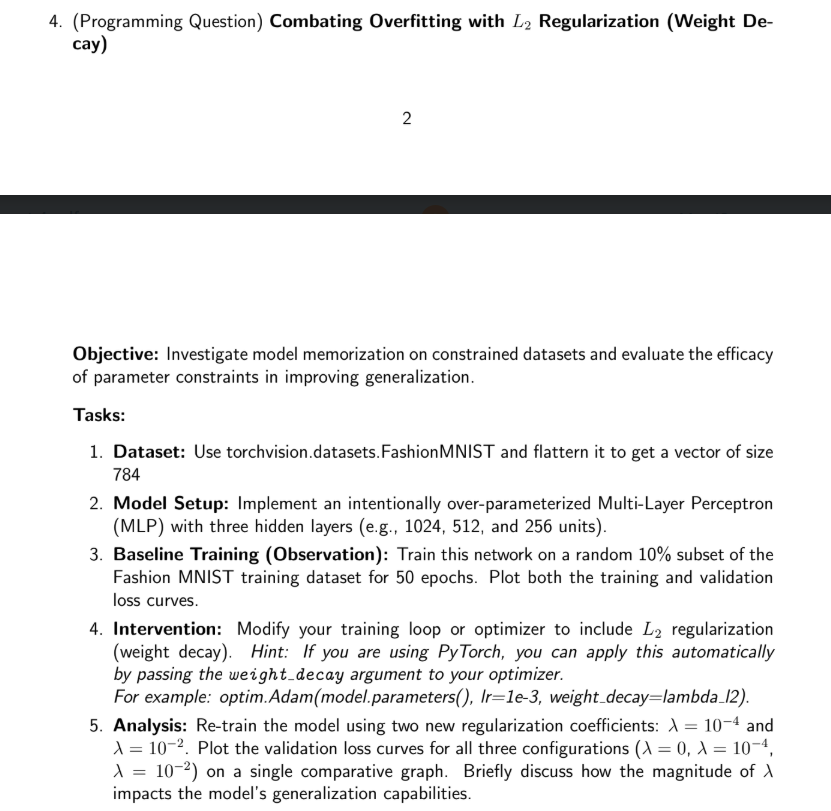

this is Combating Overfitting with L2 Regularization (Weight De-cay) on Fashion-MNIST using Pytorch implementation..
dataset split summary.
this is total training data(training + validation) i.e. 80% of the Fashion MNIST Dataset : 60000
this is total test data i.e. 20% of the Fashion MNIST Dataset : 10000


Training with λ = 0
λ=0 | Epoch 1 | Train: 0.9904 | Val: 0.6664
λ=0 | Epoch 2 | Train: 0.6076 | Val: 0.5878
λ=0 | Epoch 3 | Train: 0.5262 | Val: 0.4926
λ=0 | Epoch 4 | Train: 0.4460 | Val: 0.4833
λ=0 | Epoch 5 | Train: 0.4199 | Val: 0.4290
λ=0 | Epoch 6 | Train: 0.3940 | Val: 0.4381
λ=0 | Epoch 7 | Train: 0.3430 | Val: 0.3966
λ=0 | Epoch 8 | Train: 0.3328 | Val: 0.3989
λ=0 | Epoch 9 | Train: 0.3104 | Val: 0.4278
λ=0 | Epoch 10 | Train: 0.3177 | Val: 0.4725
λ=0 | Epoch 11 | Train: 0.3055 | Val: 0.4190
λ=0 | Epoch 12 | Train: 0.2530 | Val: 0.4163
λ=0 | Epoch 13 | Train: 0.2406 | Val: 0.4458
λ=0 | Epoch 14 | Train: 0.2262 | Val: 0.4795
λ=0 | Epoch 15 | Train: 0.2348 | Val: 0.4386
λ=0 |

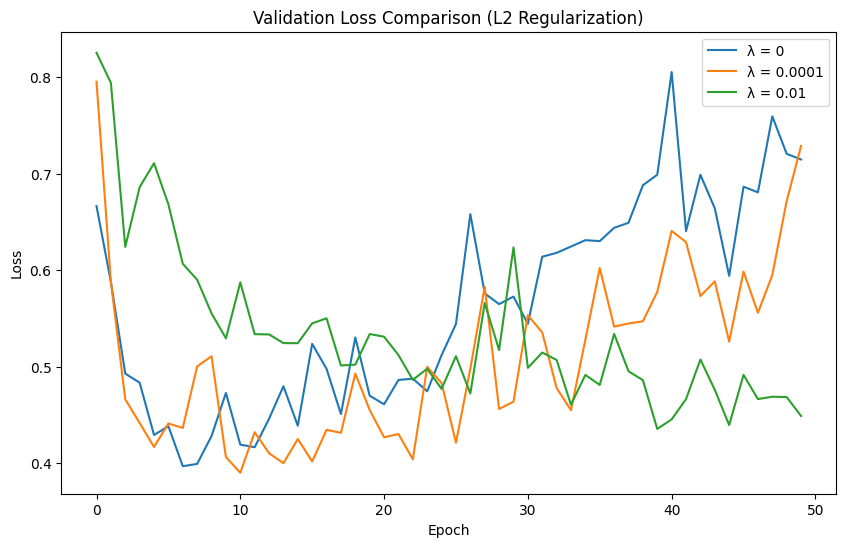

In [15]:
print(f"this is Combating Overfitting with L2 Regularization (Weight De-cay) on Fashion-MNIST using Pytorch implementation..")
print("=="*50)

#============================================
# 1. Load the Dataset
#============================================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))   # 28x28 = 784
])

training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transform,
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=transform,
)

print("dataset split summary.")
print(f"this is total training data(training + validation) i.e. 80% of the Fashion MNIST Dataset : {len(training_data)}")
print(f"this is total test data i.e. 20% of the Fashion MNIST Dataset : {len(test_data)}\n")

#==========================================================
# 2. data loaders, train and test
#==========================================================
train_size = int(0.1 * len(training_data))  # 6000
val_size = int(0.2 * train_size)         # validation from that subset
train_size = train_size - val_size

subset, _ = random_split(training_data, [int(0.1*len(training_data)), len(training_data)-int(0.1*len(training_data))])
train_data, val_data = random_split(subset, [train_size, val_size])

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64)

#==========================================================
# 3. neural network architecture
#==========================================================
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.layers = nn.Sequential(
            nn.Linear(28*28, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self,x):
        x = self.flatten(x)
        logits = self.layers(x)
        return logits


#================================================
# 4. training definition
#================================================
def train_model(weight_decay):
    model = MLP()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=weight_decay)

    train_losses = []
    val_losses = []

    for epoch in range(50):
        model.train()
        train_loss = 0

        for x, y in train_loader:
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x, y in val_loader:
                out = model(x)
                loss = criterion(out, y)
                val_loss += loss.item()

        val_loss /= len(val_loader)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"λ={weight_decay} | Epoch {epoch+1} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

    return train_losses, val_losses

#========================================
# 5. model training
#========================================
lambdas = [0, 1e-4, 1e-2]
results = {}

for lam in lambdas:
    print(f"\nTraining with λ = {lam}")
    train_l, val_l = train_model(weight_decay=lam)
    results[lam] = (train_l, val_l)


#==============================================
# 6. plot
#==============================================
plt.figure(figsize=(10,6))

for lam in lambdas:
    _, val_l = results[lam]
    plt.plot(val_l, label=f"λ = {lam}")

plt.title("Validation Loss Comparison (L2 Regularization)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [16]:
oberbations = '''
learning rate effect the convergence rate , higher learning rate it's overshoot the convergence point ,
lower learning takes time to converge but right learning rate converge quickly i.e. 0.01 in this problem statement.
'''
print(oberbations)


learning rate effect the convergence rate , higher learning rate it's overshoot the convergence point , 
lower learning takes time to converge but right learning rate converge quickly i.e. 0.01 in this problem statement.



## Question 6 : (Programming Question) Knowledge Distillation
-----

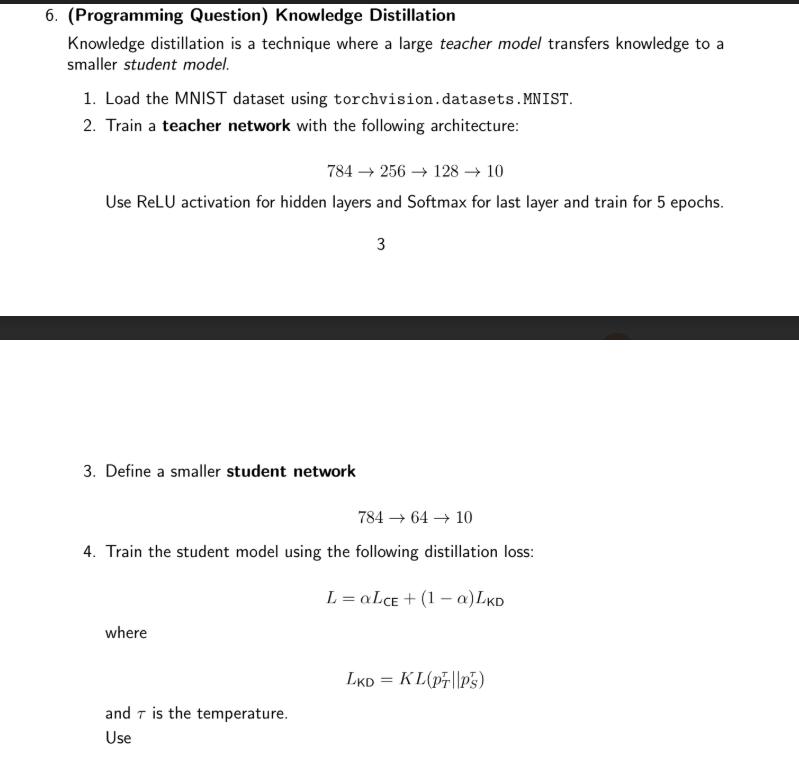

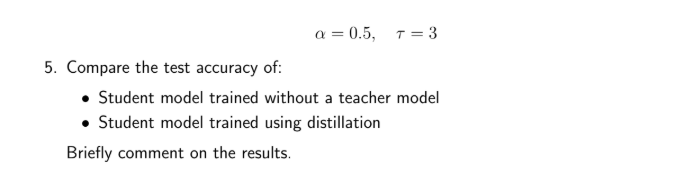

In [5]:
print(f"this is  Knowledge Distillation using Pytorch implementation..")
print("=="*50)
#============================================
# 1. Load the Dataset
#============================================

device = "cuda" if torch.cuda.is_available() else "cpu"

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))  # flatten 28x28 = 784
])

train_data = datasets.MNIST(root="data", train=True, download=True, transform=transform)
test_data  = datasets.MNIST(root="data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_data, batch_size=64)

#=================================================
# 2. Teacher Model Architecture
#=================================================

class Teacher(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)

#===================================================
# 3. Student Model Architecture
#===================================================
class Student(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.net(x)

#=================================================
# 4. Model Teacher Training Definition
#=================================================
def train_teacher():
    model = Teacher().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    model.train()
    for epoch in range(5):
        total_loss = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Teacher Epoch {epoch+1}, Loss={total_loss/len(train_loader):.4f}")

    return model
#===========================================================
# 5. Model Student Training without Distillation Definition
#===========================================================
def train_student_ce():
    model = Student().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    model.train()
    for epoch in range(5):
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

    return model

#========================================================
# 5. Model Student Training with Distillation Definition
#========================================================

def distillation_loss(student_logits, teacher_logits, y, alpha=0.5, tau=3):

    # Cross-entropy (hard labels)
    ce_loss = F.cross_entropy(student_logits, y)

    # Soft targets
    p_student = F.log_softmax(student_logits / tau, dim=1)
    p_teacher = F.softmax(teacher_logits / tau, dim=1)

    kd_loss = F.kl_div(p_student, p_teacher, reduction='batchmean') * (tau**2)

    return alpha * ce_loss + (1 - alpha) * kd_loss

def train_student_kd(teacher):
    student = Student().to(device)
    teacher.eval()

    optimizer = optim.Adam(student.parameters(), lr=1e-3)

    for epoch in range(5):
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            with torch.no_grad():
                teacher_logits = teacher(x)

            student_logits = student(x)

            loss = distillation_loss(student_logits, teacher_logits, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    return student


#====================================
# 6. Evaluation Definition
#====================================
def evaluate(model):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total

#=======================================
# 7. Model Run and Analysis
#=======================================
teacher = train_teacher()
student_ce = train_student_ce()
student_kd = train_student_kd(teacher)
print("Student (CE only) Accuracy:", evaluate(student_ce))
print("Student (Distillation) Accuracy:", evaluate(student_kd))

this is  Knowledge Distillation using Pytorch implementation..
Teacher Epoch 1, Loss=0.2824
Teacher Epoch 2, Loss=0.1069
Teacher Epoch 3, Loss=0.0697
Teacher Epoch 4, Loss=0.0496
Teacher Epoch 5, Loss=0.0378
Student (CE only) Accuracy: 0.9682
Student (Distillation) Accuracy: 0.9676


In [6]:
oberbations = '''
In this problem statemnent, the student model trained with knowledge distillation achieved accuracy comparable to the student trained with standard cross-entropy loss. However, no significant improvement was observed.
This is because MNIST is a relatively simple dataset, and the student model already has sufficient capacity to learn the task effectively without additional guidance.
'''
print(oberbations)


In this problem statemnent, the student model trained with knowledge distillation achieved accuracy comparable to the student trained with standard cross-entropy loss. However, no significant improvement was observed.
This is because MNIST is a relatively simple dataset, and the student model already has sufficient capacity to learn the task effectively without additional guidance.



## Question 8 :Skip connections (also known as residual connections)
----

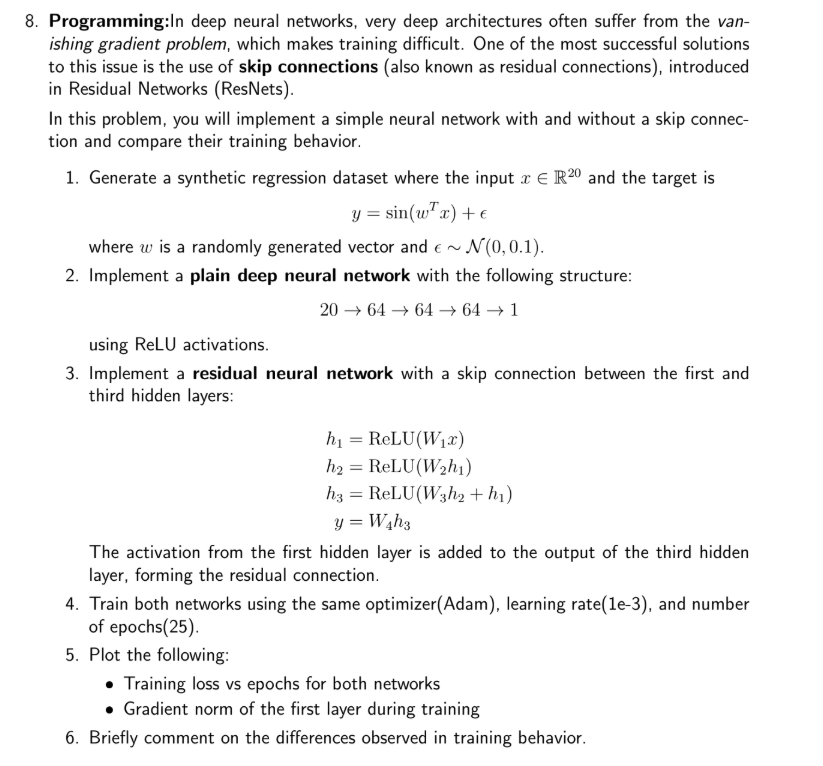

Training Plain Network...
Epoch 10: Train=0.5111, Val=0.5195
Epoch 20: Train=0.5061, Val=0.5174
Epoch 30: Train=0.5022, Val=0.5169
Epoch 40: Train=0.4967, Val=0.5167
Epoch 50: Train=0.4878, Val=0.5172

Training Residual Network...
Epoch 10: Train=0.5216, Val=0.5341
Epoch 20: Train=0.5110, Val=0.5252
Epoch 30: Train=0.5044, Val=0.5223
Epoch 40: Train=0.4981, Val=0.5214
Epoch 50: Train=0.4913, Val=0.5220


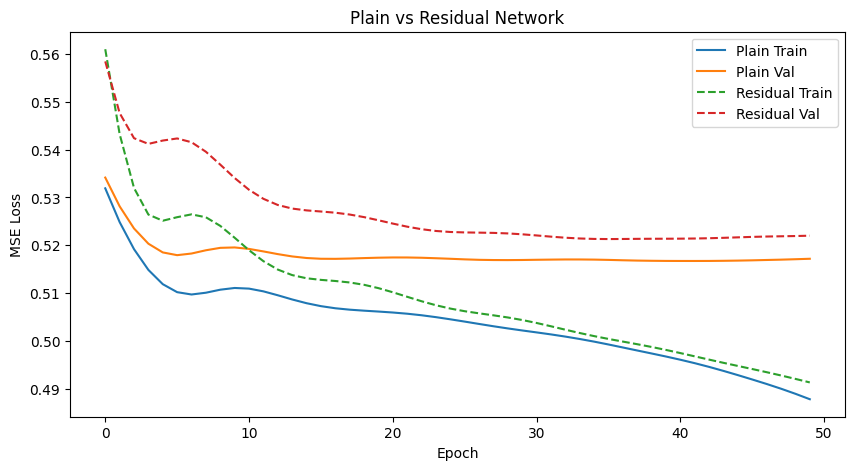

In [17]:
#============================================
# 1. data definition
#============================================
# Reproducibility
torch.manual_seed(42)

# Data
N = 5000
input_dim = 20
X = torch.randn(N, input_dim)

# true weight
w_true = torch.randn(input_dim)
# target: y = sin(w^T x) + noise
y = torch.sin(X @ w_true) + 0.1 * torch.randn(N)
y = y.unsqueeze(1)  # shape (N,1)

train_size = int(0.8 * N)
X_train, X_val = X[:train_size], X[train_size:]
y_train, y_val = y[:train_size], y[train_size:]

#==========================================================
# 2. neural network architecture
#==========================================================
class PlainNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(20, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)

#==========================================================
# 3. Residual Net
#==========================================================
class ResidualNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(20, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 64)
        self.fc4 = nn.Linear(64, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        h1 = self.relu(self.fc1(x))
        h2 = self.relu(self.fc2(h1))
        h3 = self.relu(self.fc3(h2) + h1)  # skip connection
        out = self.fc4(h3)
        return out

#==========================================================
# 4. Training Definition
#==========================================================
def train_model(model, epochs=50, lr=0.001):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        # Train
        model.train()
        optimizer.zero_grad()
        pred = model(X_train)
        loss = criterion(pred, y_train)
        loss.backward()
        optimizer.step()

        # Validation
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val)
            val_loss = criterion(val_pred, y_val)

        train_losses.append(loss.item())
        val_losses.append(val_loss.item())

        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}: Train={loss.item():.4f}, Val={val_loss.item():.4f}")

    return train_losses, val_losses

#=====================================================
# 5. Model Training
#=====================================================
plain_model = PlainNet()
res_model = ResidualNet()

print("Training Plain Network...")
plain_train, plain_val = train_model(plain_model)

print("\nTraining Residual Network...")
res_train, res_val = train_model(res_model)

#===================================================
# 6. plotting the oberbations
#===================================================
plt.figure(figsize=(10,5))

plt.plot(plain_train, label="Plain Train")
plt.plot(plain_val, label="Plain Val")

plt.plot(res_train, '--', label="Residual Train")
plt.plot(res_val, '--', label="Residual Val")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Plain vs Residual Network")
plt.legend()
plt.show()

In [18]:
oberbations = '''
1. Residual netwrork converges faster.
2. It achieves usually better minima.
'''
print(oberbations)


1. Residual netwrork converges faster.
2. It achieves usually better minima.



## Question 9 : (Programming Question) Early Stopping
----

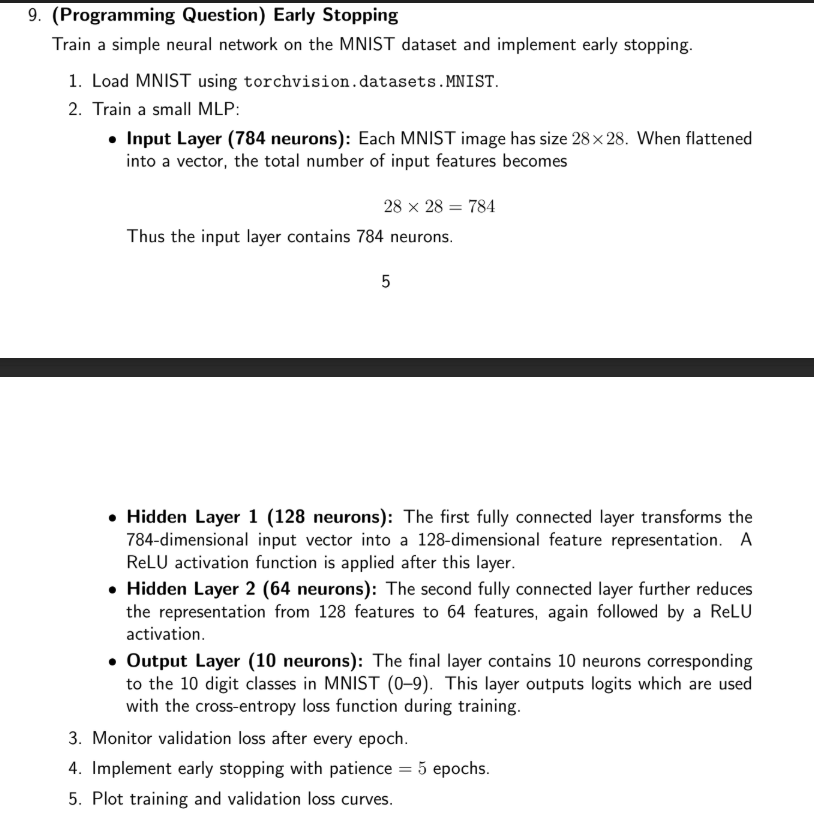

this is Early Stopping MNIST using Pytorch implementation..
dataset  summary.
this is toatl data(training + validation + Test) i.e.  MNIST Dataset : 60000

Epoch 1: Train Loss=0.3854, Val Loss=0.2070
Epoch 2: Train Loss=0.1622, Val Loss=0.1302
Epoch 3: Train Loss=0.1105, Val Loss=0.1129
Epoch 4: Train Loss=0.0841, Val Loss=0.1026
Epoch 5: Train Loss=0.0656, Val Loss=0.0988
Epoch 6: Train Loss=0.0530, Val Loss=0.0900
Epoch 7: Train Loss=0.0424, Val Loss=0.0878
Epoch 8: Train Loss=0.0355, Val Loss=0.0820
Epoch 9: Train Loss=0.0297, Val Loss=0.0863
Epoch 10: Train Loss=0.0243, Val Loss=0.1013
Epoch 11: Train Loss=0.0210, Val Loss=0.0912
Epoch 12: Train Loss=0.0178, Val Loss=0.0984
Epoch 13: Train Loss=0.0172, Val Loss=0.0987

Early stopping triggered at epoch 13


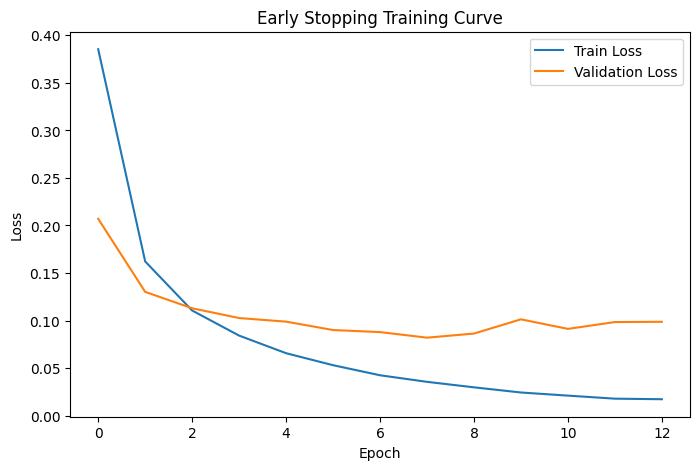

In [19]:
print(f"this is Early Stopping MNIST using Pytorch implementation..")
print("=="*50)

#============================================
# 1. Load the Dataset
#============================================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))   # 28x28 = 784
])

data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=transform,
)

print("dataset  summary.")
print(f"this is toatl data(training + validation + Test) i.e.  MNIST Dataset : {len(data)}\n")

#==========================================================
# 2. data loaders, train and validation
#==========================================================
train_size = int(0.8 * len(data))
val_size = len(data) - train_size

train_data, val_data = random_split(data, [train_size, val_size])

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64)

#==========================================================
# 3. neural network architecture
#==========================================================
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.layers = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10),
        )

    def forward(self,x):
        x = self.flatten(x)
        logits = self.layers(x)
        return logits

#========================================================
# 4. Early stopping definition
#========================================================
def train_with_early_stopping(patience=5, max_epochs=50):
    model = MLP()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    best_val_loss = float('inf')
    patience_counter = 0

    train_losses = []
    val_losses = []

    for epoch in range(max_epochs):
        #------------------------------
        # train
        #------------------------------
        model.train()
        train_loss = 0

        for x, y in train_loader:
            optimizer.zero_grad()
            output = model(x)
            loss = criterion(output, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)

        #------------------------------
        # validation
        #------------------------------
        model.eval()
        val_loss = 0

        with torch.no_grad():
            for x, y in val_loader:
                output = model(x)
                loss = criterion(output, y)
                val_loss += loss.item()

        val_loss /= len(val_loader)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")

        #---------------------------
        # early stopping
        #---------------------------
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model = model.state_dict()  # save best model
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            break
    # Load best model
    model.load_state_dict(best_model)
    return model, train_losses, val_losses

# ===============================================
# 5. training execuition + plotting
#================================================
model, train_losses, val_losses = train_with_early_stopping(patience=5)

plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Early Stopping Training Curve")
plt.legend()
plt.show()

## Question 12 . Programming: Noise Injection as Regularization


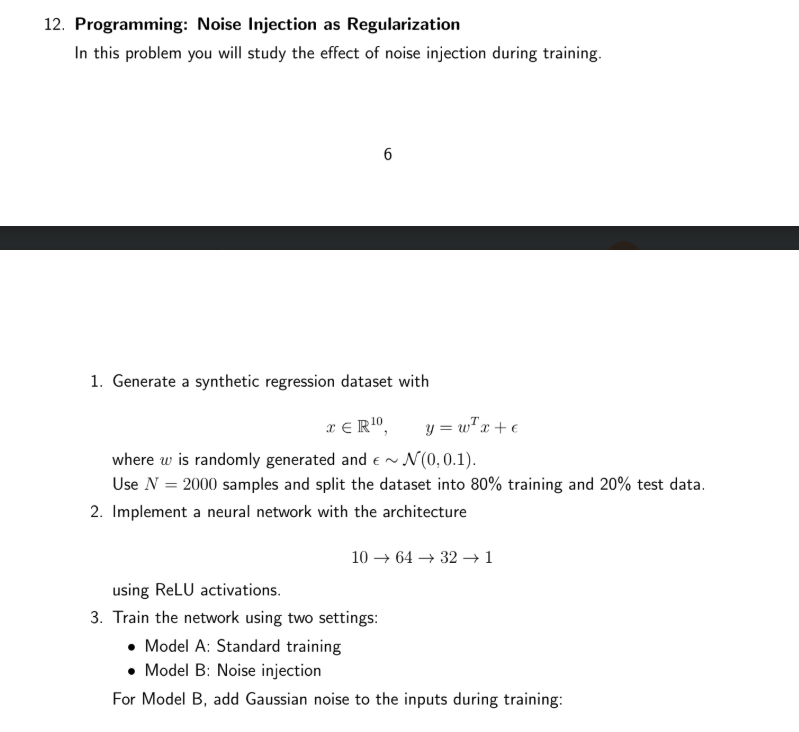

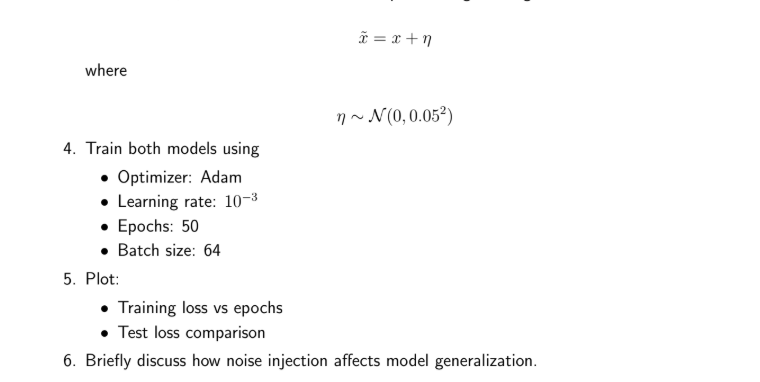

this is Noise Injection as Regularization using Pytorch implementation..
Training Model A (No Noise)...
Epoch 10: Train=0.0733, Test=0.0686
Epoch 20: Train=0.0299, Test=0.0329
Epoch 30: Train=0.0222, Test=0.0285
Epoch 40: Train=0.0184, Test=0.0253
Epoch 50: Train=0.0155, Test=0.0238

Training Model B (With Noise)...
Epoch 10: Train=0.1080, Test=0.0564
Epoch 20: Train=0.0759, Test=0.0376
Epoch 30: Train=0.0681, Test=0.0283
Epoch 40: Train=0.0569, Test=0.0263
Epoch 50: Train=0.0560, Test=0.0217


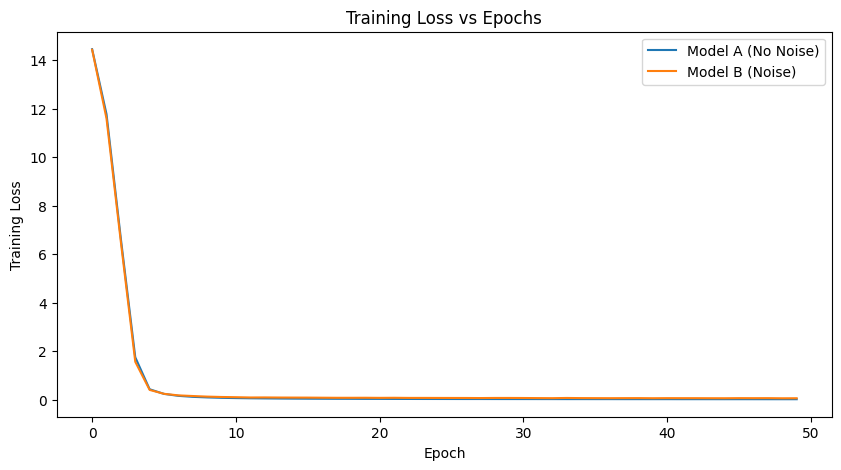

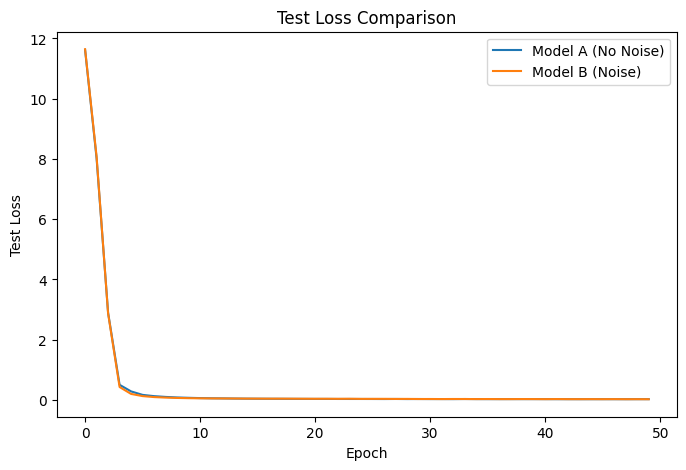

In [20]:
print(f"this is Noise Injection as Regularization using Pytorch implementation..")
print("=="*50)

#============================================
# 1. data definition
#============================================
# reproducibility
torch.manual_seed(42)

# data
N = 2000
input_dim = 10
X = torch.randn(N, input_dim)
w_true = torch.randn(input_dim)

# y = w^T x + noise
y = X @ w_true + 0.1 * torch.randn(N)
y = y.unsqueeze(1)

train_size = int(0.8 * N)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=64)

#============================================
# 2. Neural Network
#============================================

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(10, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.model(x)

#==========================================
# 3. model training definition
#==========================================
def train_model(model, train_loader, test_loader, noise_std=0.0, epochs=50):
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()

    train_losses = []
    test_losses = []

    for epoch in range(epochs):
        # train
        model.train()
        total_train_loss = 0

        for x_batch, y_batch in train_loader:

            #  Noise Injection (only during training)
            if noise_std > 0:
                noise = torch.randn_like(x_batch) * noise_std
                x_batch = x_batch + noise

            optimizer.zero_grad()
            preds = model(x_batch)
            loss = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)

        # test
        model.eval()
        total_test_loss = 0

        with torch.no_grad():
            for x_batch, y_batch in test_loader:
                preds = model(x_batch)
                loss = criterion(preds, y_batch)
                total_test_loss += loss.item()

        avg_test_loss = total_test_loss / len(test_loader)

        train_losses.append(avg_train_loss)
        test_losses.append(avg_test_loss)

        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}: Train={avg_train_loss:.4f}, Test={avg_test_loss:.4f}")

    return train_losses, test_losses

#========================================
# 4. model training
#========================================
# Model A: Standard
model_A = Net()
print("Training Model A (No Noise)...")
train_A, test_A = train_model(model_A, train_loader, test_loader, noise_std=0.0)

# Model B: Noise Injection
model_B = Net()
print("\nTraining Model B (With Noise)...")
train_B, test_B = train_model(model_B, train_loader, test_loader, noise_std=0.05)

#=========================================
# 5. Training Loss
#=========================================
plt.figure(figsize=(10,5))
plt.plot(train_A, label="Model A (No Noise)")
plt.plot(train_B, label="Model B (Noise)")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epochs")
plt.legend()
plt.show()

#=========================================
# 6. Test Loss
#=========================================
plt.figure(figsize=(8,5))
plt.plot(test_A, label="Model A (No Noise)")
plt.plot(test_B, label="Model B (Noise)")
plt.xlabel("Epoch")
plt.ylabel("Test Loss")
plt.title("Test Loss Comparison")
plt.legend()
plt.show()

In [21]:
oberbations = '''
Training Loss :
Model A : lower training loss
Model B : slightly higher (due to noise)

Test Loss:
Model A : may overfit
Model B : usually better generalization (lower test loss)
'''
print(oberbations)



Training Loss : 
Model A : lower training loss
Model B : slightly higher (due to noise)

Test Loss:
Model A : may overfit
Model B : usually better generalization (lower test loss)



## Question 14 : Programming: Empirical Comparison of SGD, Nesterov and L-BFGS
----


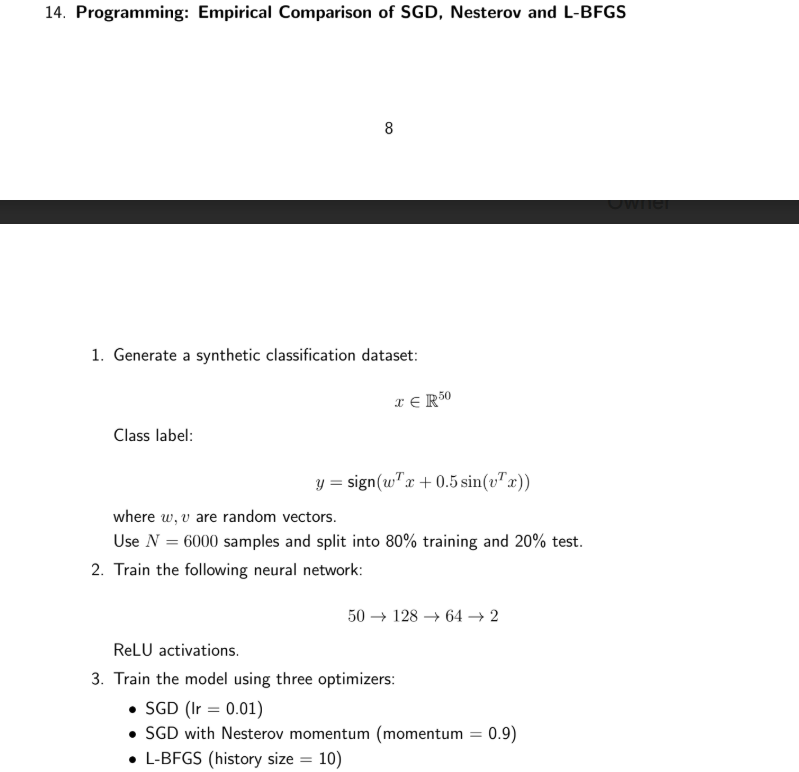

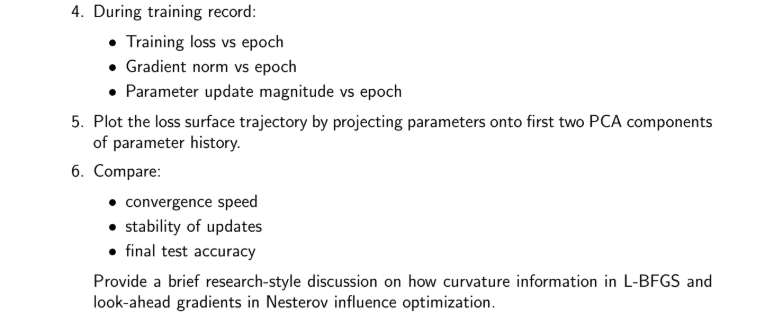

this is Empirical Comparison of SGD, Nesterov and L-BFGS using Pytorch implementation.
SGD Epoch 1: Loss=0.6885
SGD Epoch 2: Loss=0.6728
SGD Epoch 3: Loss=0.6535
SGD Epoch 4: Loss=0.6270
SGD Epoch 5: Loss=0.5897
SGD Epoch 6: Loss=0.5396
SGD Epoch 7: Loss=0.4794
SGD Epoch 8: Loss=0.4154
SGD Epoch 9: Loss=0.3560
SGD Epoch 10: Loss=0.3056
SGD Epoch 11: Loss=0.2647
SGD Epoch 12: Loss=0.2324
SGD Epoch 13: Loss=0.2068
SGD Epoch 14: Loss=0.1864
SGD Epoch 15: Loss=0.1697
SGD Epoch 16: Loss=0.1558
SGD Epoch 17: Loss=0.1443
SGD Epoch 18: Loss=0.1345
SGD Epoch 19: Loss=0.1258
SGD Epoch 20: Loss=0.1181
NESTEROV Epoch 1: Loss=0.6701
NESTEROV Epoch 2: Loss=0.3827
NESTEROV Epoch 3: Loss=0.1381
NESTEROV Epoch 4: Loss=0.0845
NESTEROV Epoch 5: Loss=0.0582
NESTEROV Epoch 6: Loss=0.0428
NESTEROV Epoch 7: Loss=0.0319
NESTEROV Epoch 8: Loss=0.0219
NESTEROV Epoch 9: Loss=0.0180
NESTEROV Epoch 10: Loss=0.0129
NESTEROV Epoch 11: Loss=0.0097
NESTEROV Epoch 12: Loss=0.0078
NESTEROV Epoch 13: Loss=0.0063
NESTEROV

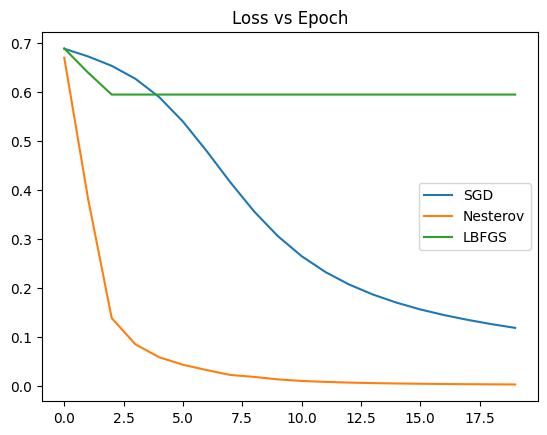

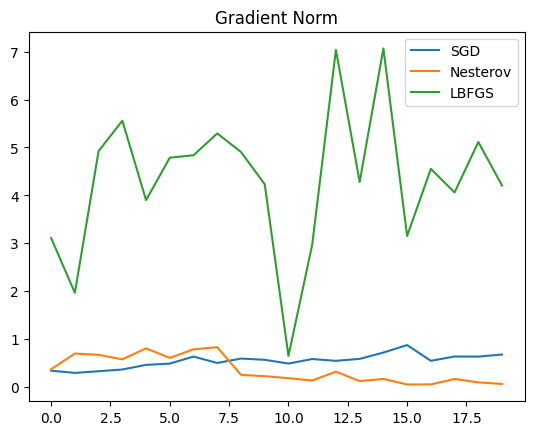

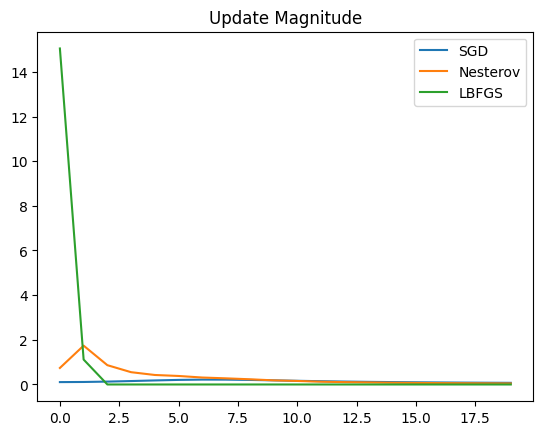

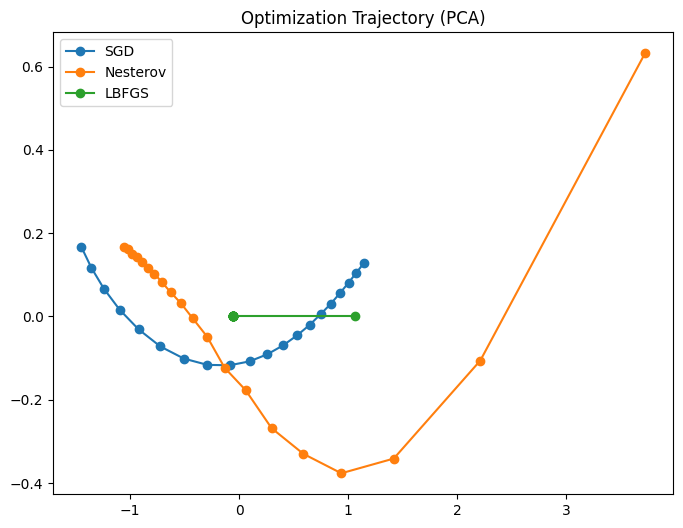

SGD Acc: 0.9516666666666667
Nesterov Acc: 0.9508333333333333
LBFGS Acc: 0.91


<Figure size 640x480 with 0 Axes>

In [22]:
print(f"this is Empirical Comparison of SGD, Nesterov and L-BFGS using Pytorch implementation.")
print("=="*50)

#============================================
# 1. data definition
#============================================

torch.manual_seed(42)
# Data
N = 6000
d = 50
X = torch.randn(N, d)
w = torch.randn(d)
v = torch.randn(d)
# Labels: sign(w^T x + 0.5 sin(v^T x))
y = torch.sign(X @ w + 0.5 * torch.sin(X @ v))
y[y == -1] = 0  # convert to {0,1}
y = y.long()
# Train-test split
train_size = int(0.8 * N)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=64)

#============================================
# 2. Neural Network
#============================================
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(50, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.net(x)

#==========================================
# 3. Auto Grad + Paramter Vector
#==========================================

def compute_grad_norm(model):
    total = 0
    for p in model.parameters():
        if p.grad is not None:
            total += p.grad.norm().item()**2
    return total**0.5

def get_param_vector(model):
    return torch.cat([p.data.view(-1) for p in model.parameters()])

#==========================================
# 4. model training definition
#==========================================

def train_model(optimizer_type="sgd"):
    model = Net()
    criterion = nn.CrossEntropyLoss()

    # Optimizers
    if optimizer_type == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=0.01)

    elif optimizer_type == "nesterov":
        optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, nesterov=True)

    elif optimizer_type == "lbfgs":
        optimizer = optim.LBFGS(model.parameters(), lr=0.01, history_size=10)

    losses = []
    grad_norms = []
    update_magnitudes = []
    param_history = []

    prev_params = get_param_vector(model).clone()

    for epoch in range(20):   # keep small for LBFGS
        total_loss = 0

        for X_batch, y_batch in train_loader:

            def closure():
                optimizer.zero_grad()
                output = model(X_batch)
                loss = criterion(output, y_batch)
                loss.backward()
                return loss

            if optimizer_type == "lbfgs":
                loss = optimizer.step(closure)
            else:
                optimizer.zero_grad()
                output = model(X_batch)
                loss = criterion(output, y_batch)
                loss.backward()
                optimizer.step()

            total_loss += loss.item()

        # Metrics
        losses.append(total_loss / len(train_loader))
        grad_norms.append(compute_grad_norm(model))

        # Update magnitude
        curr_params = get_param_vector(model)
        update_magnitude = torch.norm(curr_params - prev_params).item()
        update_magnitudes.append(update_magnitude)

        prev_params = curr_params.clone()
        param_history.append(curr_params.numpy())

        print(f"{optimizer_type.upper()} Epoch {epoch+1}: Loss={losses[-1]:.4f}")

    return model, losses, grad_norms, update_magnitudes, param_history


#====================================================================
# 5.Training the models
#====================================================================
sgd_model, sgd_loss, sgd_grad, sgd_update, sgd_params = train_model("sgd")
nest_model, nest_loss, nest_grad, nest_update, nest_params = train_model("nesterov")
lbfgs_model, lbfgs_loss, lbfgs_grad, lbfgs_update, lbfgs_params = train_model("lbfgs")

#=========================================================
# 6. Plotting
#=========================================================
plt.plot(sgd_loss, label="SGD")
plt.plot(nest_loss, label="Nesterov")
plt.plot(lbfgs_loss, label="LBFGS")
plt.title("Loss vs Epoch")
plt.legend()
plt.show()

plt.plot(sgd_grad, label="SGD")
plt.plot(nest_grad, label="Nesterov")
plt.plot(lbfgs_grad, label="LBFGS")
plt.title("Gradient Norm")
plt.legend()
plt.show()

plt.plot(sgd_update, label="SGD")
plt.plot(nest_update, label="Nesterov")
plt.plot(lbfgs_update, label="LBFGS")
plt.title("Update Magnitude")
plt.legend()
plt.show()

#==========================================
# 7. PCA Trajectory
#=========================================
def plot_pca_trajectory(param_hist, label):
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(param_hist)

    plt.plot(reduced[:,0], reduced[:,1], marker='o', label=label)

plt.figure(figsize=(8,6))
plot_pca_trajectory(sgd_params, "SGD")
plot_pca_trajectory(nest_params, "Nesterov")
plot_pca_trajectory(lbfgs_params, "LBFGS")

plt.title("Optimization Trajectory (PCA)")
plt.legend()
plt.show()
plt.tight_layout()

#==========================================
# 8. Model Evaluation
#=========================================
def evaluate(model):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            pred = model(X_batch).argmax(dim=1)
            correct += (pred == y_batch).sum().item()
            total += y_batch.size(0)

    return correct / total

print("SGD Acc:", evaluate(sgd_model))
print("Nesterov Acc:", evaluate(nest_model))
print("LBFGS Acc:", evaluate(lbfgs_model))

## Question 15 .Programming + Conceptual Question: Autoencoders with Regularization
----


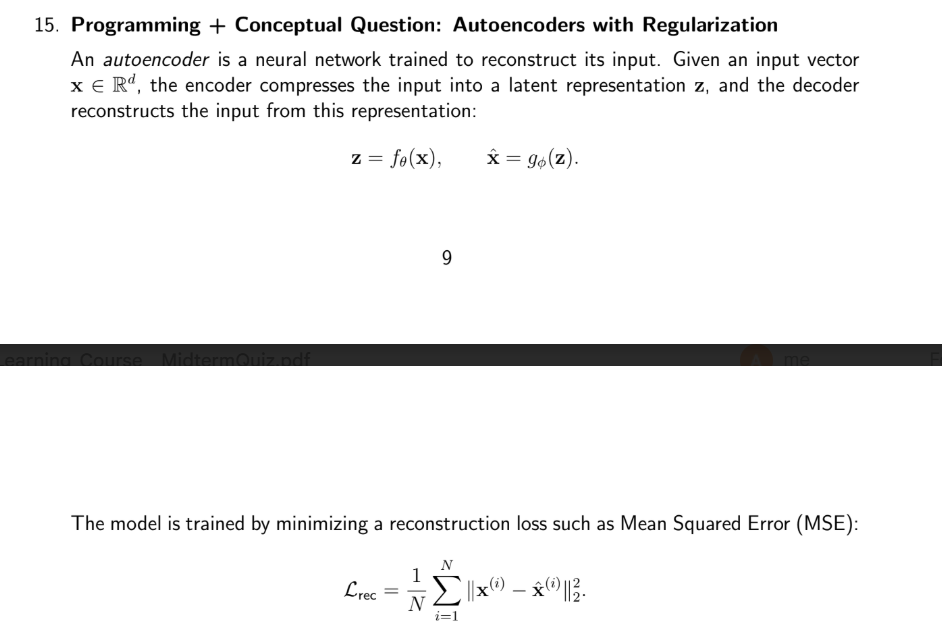

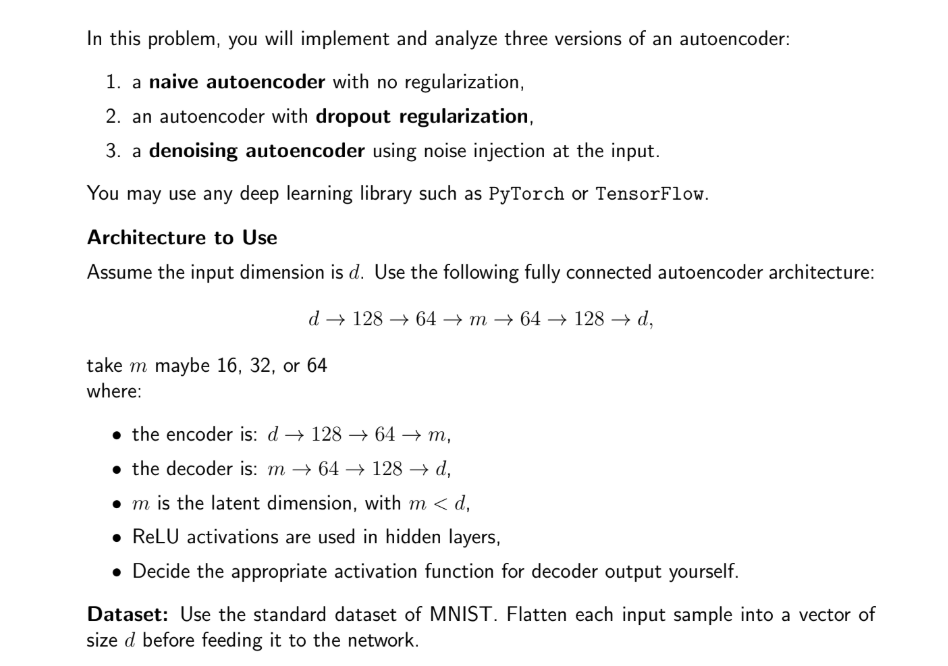

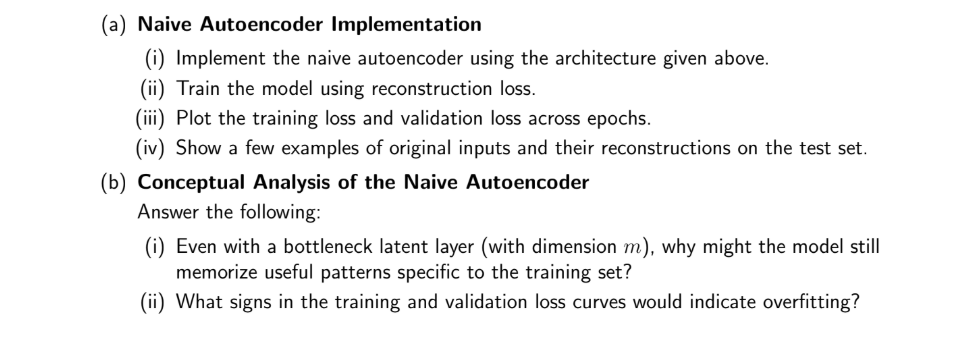

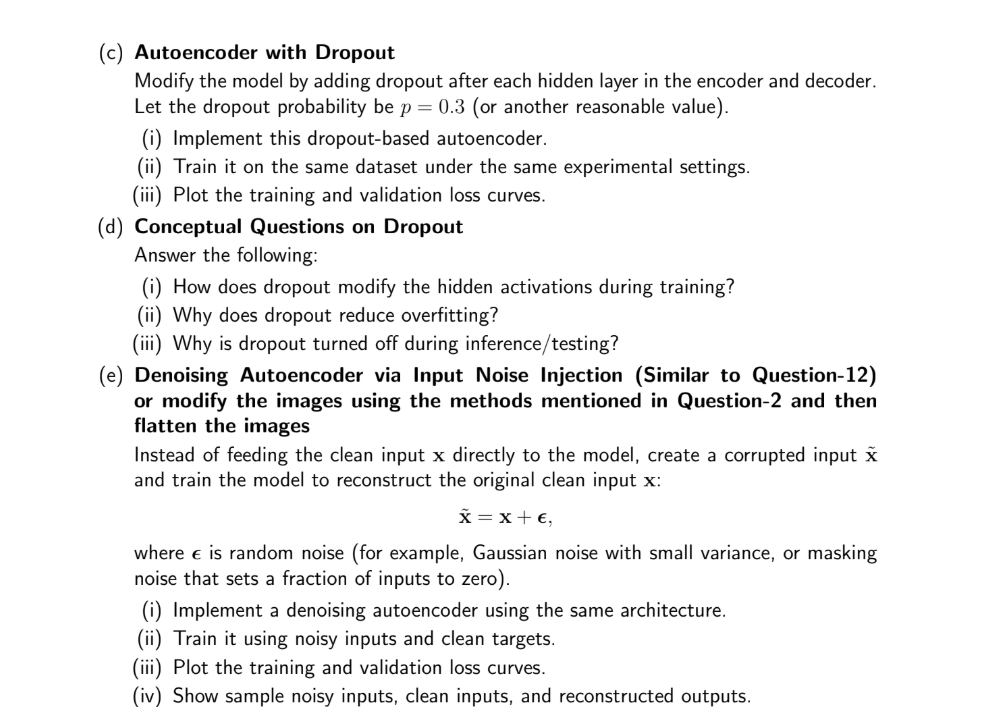

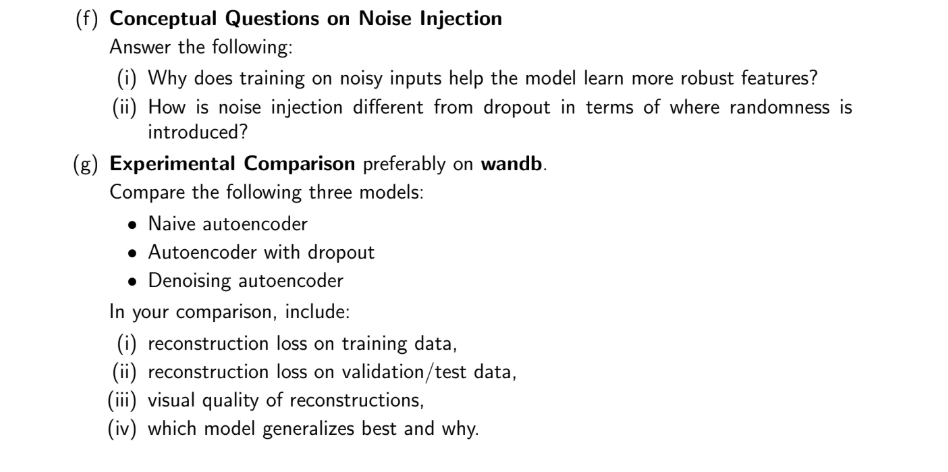

this is Autoencoders with Regularization using Pytorch implementation.
Epoch 1: Train=0.0659, Val=0.0410
Epoch 2: Train=0.0344, Val=0.0299
Epoch 3: Train=0.0277, Val=0.0256
Epoch 4: Train=0.0242, Val=0.0229
Epoch 5: Train=0.0218, Val=0.0208
Epoch 6: Train=0.0199, Val=0.0190
Epoch 7: Train=0.0184, Val=0.0177
Epoch 8: Train=0.0173, Val=0.0169
Epoch 9: Train=0.0164, Val=0.0159
Epoch 10: Train=0.0154, Val=0.0150
Epoch 11: Train=0.0145, Val=0.0142
Epoch 12: Train=0.0138, Val=0.0135
Epoch 13: Train=0.0132, Val=0.0131
Epoch 14: Train=0.0126, Val=0.0124
Epoch 15: Train=0.0122, Val=0.0121
Epoch 16: Train=0.0118, Val=0.0117
Epoch 17: Train=0.0115, Val=0.0115
Epoch 18: Train=0.0113, Val=0.0112
Epoch 19: Train=0.0110, Val=0.0110
Epoch 20: Train=0.0107, Val=0.0108
Epoch 1: Train=0.0716, Val=0.0517
Epoch 2: Train=0.0495, Val=0.0406
Epoch 3: Train=0.0439, Val=0.0363
Epoch 4: Train=0.0416, Val=0.0344
Epoch 5: Train=0.0405, Val=0.0333
Epoch 6: Train=0.0398, Val=0.0328
Epoch 7: Train=0.0393, Val=0.0322


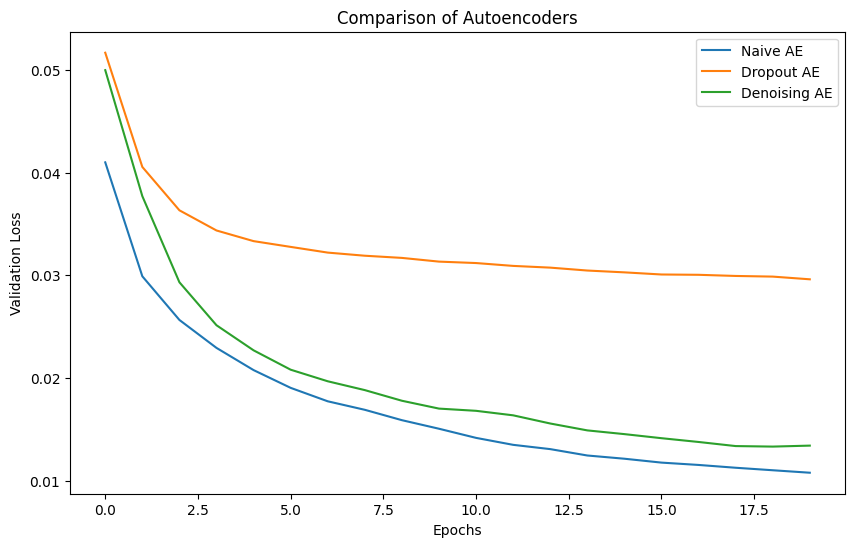

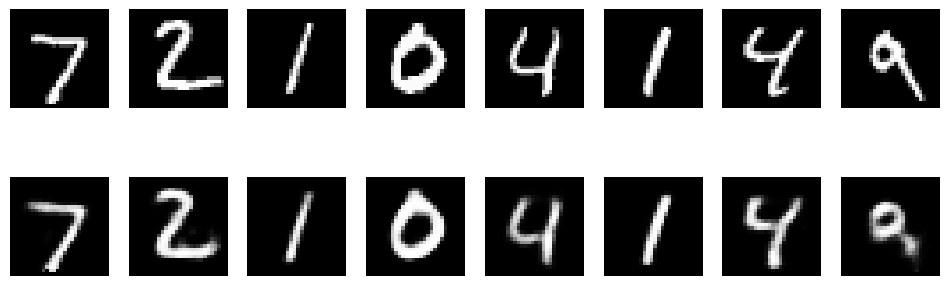

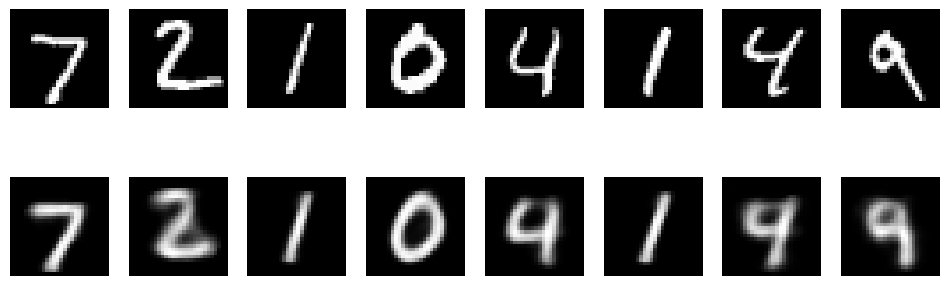

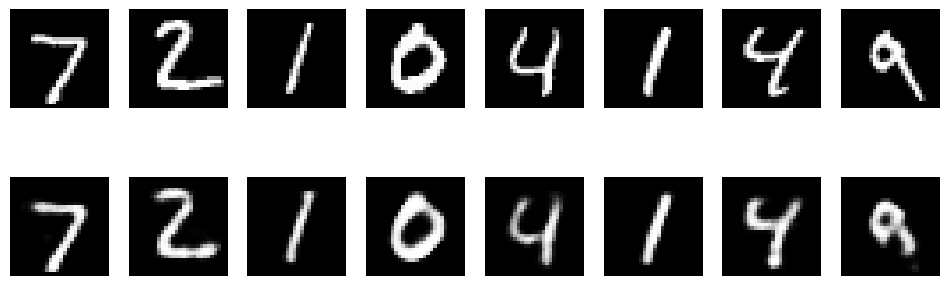

In [12]:

print(f"this is Autoencoders with Regularization using Pytorch implementation.")
print("=="*50)

#============================================
# 1. data definition
#============================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))  # flatten 784
])

dataset = datasets.MNIST(root="data", train=True, download=True, transform=transform)

# Train / Val split
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_data, val_data = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
val_loader = DataLoader(val_data, batch_size=128)

test_data = datasets.MNIST(root="data", train=False, transform=transform)
test_loader = DataLoader(test_data, batch_size=128)

#============================================
# 2. Autoencoder
#============================================
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=32, dropout=False):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Dropout(0.3) if dropout else nn.Identity(),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3) if dropout else nn.Identity(),

            nn.Linear(64, latent_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3) if dropout else nn.Identity(),

            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Dropout(0.3) if dropout else nn.Identity(),

            nn.Linear(128, 784),
            nn.Sigmoid()   # IMPORTANT for pixel values [0,1]
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat

#===========================================
# 3. train model definition
#===========================================

def train_model(model, train_loader, val_loader, epochs=20, noise=False):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        # train
        model.train()
        total_train_loss = 0

        for x, _ in train_loader:
            x = x.to(device)

            # Noise injection (for denoising AE)
            if noise:
                noisy_x = x + 0.1 * torch.randn_like(x)
                noisy_x = torch.clamp(noisy_x, 0., 1.)
            else:
                noisy_x = x

            optimizer.zero_grad()
            x_hat = model(noisy_x)
            loss = criterion(x_hat, x)   # reconstruct clean x
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

        train_losses.append(total_train_loss / len(train_loader))

        # validation
        model.eval()
        total_val_loss = 0

        with torch.no_grad():
            for x, _ in val_loader:
                x = x.to(device)
                x_hat = model(x)
                loss = criterion(x_hat, x)
                total_val_loss += loss.item()

        val_losses.append(total_val_loss / len(val_loader))

        print(f"Epoch {epoch+1}: Train={train_losses[-1]:.4f}, Val={val_losses[-1]:.4f}")

    return train_losses, val_losses


#====================================
# 4. Model Training
#===================================
# 1. Naive AE
naive_model = Autoencoder(latent_dim=32, dropout=False)
naive_train, naive_val = train_model(naive_model, train_loader, val_loader)

# 2. Dropout AE
drop_model = Autoencoder(latent_dim=32, dropout=True)
drop_train, drop_val = train_model(drop_model, train_loader, val_loader)

# 3. Denoising AE
denoise_model = Autoencoder(latent_dim=32, dropout=False)
denoise_train, denoise_val = train_model(denoise_model, train_loader, val_loader, noise=True)


#=====================================
# 5. Loss Comparision
#=====================================
plt.figure(figsize=(10,6))

plt.plot(naive_val, label="Naive AE")
plt.plot(drop_val, label="Dropout AE")
plt.plot(denoise_val, label="Denoising AE")

plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.title("Comparison of Autoencoders")
plt.legend()
plt.show()

#======================================
# 6. Reconstruction
#======================================
def show_reconstructions(model, loader, noise=False):
    model.eval()

    x, _ = next(iter(loader))
    x = x.to(device)

    if noise:
        noisy_x = x + 0.1 * torch.randn_like(x)
        noisy_x = torch.clamp(noisy_x, 0., 1.)
    else:
        noisy_x = x

    with torch.no_grad():
        x_hat = model(noisy_x)

    x = x.cpu().view(-1, 28, 28)
    x_hat = x_hat.cpu().view(-1, 28, 28)

    fig, axes = plt.subplots(2, 8, figsize=(12,4))

    for i in range(8):
        axes[0, i].imshow(x[i], cmap='gray')
        axes[0, i].axis('off')

        axes[1, i].imshow(x_hat[i], cmap='gray')
        axes[1, i].axis('off')

    plt.show()

#==================================
#  7. Results
#==================================
show_reconstructions(naive_model, test_loader)
show_reconstructions(drop_model, test_loader)
show_reconstructions(denoise_model, test_loader, noise=True)

In [23]:
oberbations = '''
(b) Naive AE
(i)  memorization : High model capacity , Learns identity mapping and Even bottleneck may still encode dataset-specific patterns
(ii) Overfitting signs: Train loss decreases abd Validation loss increases

(d) Dropout
(i) Effect: Randomly zeroes neurons during training
(ii) Why reduces overfitting:Prevents co-adaptation , Acts like ensemble
(iii) Why off in testing: Use full network capacity

(f) Noise Injection
(i) Why robust features: Model learns to ignore noise , Captures stable structure
'''

print(oberbations)


(b) Naive AE
(i)  memorization : High model capacity , Learns identity mapping and Even bottleneck may still encode dataset-specific patterns
(ii) Overfitting signs: Train loss decreases abd Validation loss increases

(d) Dropout
(i) Effect: Randomly zeroes neurons during training
(ii) Why reduces overfitting:Prevents co-adaptation , Acts like ensemble
(iii) Why off in testing: Use full network capacity

(f) Noise Injection
(i) Why robust features: Model learns to ignore noise , Captures stable structure

